In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Load datasets

historical_data = pd.read_csv("data/historical_data.csv")
fear_greed = pd.read_csv("data/fear_greed_index.csv")

print("Historical Data Shape:", historical_data.shape)
print("Fear & Greed Shape:", fear_greed.shape)

Historical Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


In [5]:
# Display first five rows

print("Historical Data")
display(historical_data.head())

print("Fear & Greed Index")
display(fear_greed.head())

Historical Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Fear & Greed Index


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
# Check missing values

print("Historical Data Missing Values")
print(historical_data.isnull().sum())

print("\nFear & Greed Missing Values")
print(fear_greed.isnull().sum())

Historical Data Missing Values
Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
                  ..
Order ID           0
Crossed            0
Fee                0
Trade ID           0
Timestamp          0
Length: 16, dtype: int64

Fear & Greed Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [7]:
# Convert date columns to datetime

historical_data["Timestamp IST"] = pd.to_datetime(
    historical_data["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

fear_greed["date"] = pd.to_datetime(fear_greed["date"])

# Extract only the date
historical_data["Date"] = historical_data["Timestamp IST"].dt.date
fear_greed["Date"] = fear_greed["date"].dt.date

print("Date conversion completed!")


Date conversion completed!


In [8]:
# Merge trader data with Fear & Greed data

merged_data = pd.merge(
    historical_data,
    fear_greed[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

print("Merged Dataset Shape:", merged_data.shape)
merged_data.head()

Merged Dataset Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [9]:
# Check whether every trade received a sentiment label

print(merged_data[["Date", "classification", "value"]].head(10))

print("\nMissing sentiment values:")
print(merged_data["classification"].isnull().sum())

         Date classification  value
0  2024-12-02  Extreme Greed   80.0
1  2024-12-02  Extreme Greed   80.0
2  2024-12-02  Extreme Greed   80.0
3  2024-12-02  Extreme Greed   80.0
4  2024-12-02  Extreme Greed   80.0
5  2024-12-02  Extreme Greed   80.0
6  2024-12-02  Extreme Greed   80.0
7  2024-12-02  Extreme Greed   80.0
8  2024-12-02  Extreme Greed   80.0
9  2024-12-02  Extreme Greed   80.0

Missing sentiment values:
6


In [10]:
# Find rows where sentiment is missing

missing_dates = merged_data[merged_data["classification"].isna()][["Date"]].drop_duplicates()

print(missing_dates)
print("\nNumber of missing dates:", len(missing_dates))

           Date
727  2024-10-26

Number of missing dates: 1


In [11]:
# Remove rows without sentiment

merged_data = merged_data.dropna(subset=["classification"])

print("New Shape:", merged_data.shape)
print("Missing sentiments:", merged_data["classification"].isna().sum())

New Shape: (211218, 19)
Missing sentiments: 0


In [12]:
print("Total Trades:", len(merged_data))

print("Total Profit/Loss:", merged_data["Closed PnL"].sum())

print("Average Profit:", merged_data["Closed PnL"].mean())

print("Median Profit:", merged_data["Closed PnL"].median())

Total Trades: 211218
Total Profit/Loss: 10254486.949306
Average Profit: 48.54930427002434
Median Profit: 0.0


In [13]:
sentiment_profit = (
    merged_data
    .groupby("classification")["Closed PnL"]
    .agg(["count", "mean", "sum", "median"])
    .sort_values("mean", ascending=False)
)

display(sentiment_profit)

,count,mean,sum,median
classification,,,,
Extreme Greed,39992,67.892861,2.715171e+06,0.0
Fear,61837,54.290400,3.357155e+06,0.0
Greed,50303,42.743559,2.150129e+06,0.0
Extreme Fear,21400,34.537862,7.391102e+05,0.0
Neutral,37686,34.307718,1.292921e+06,0.0


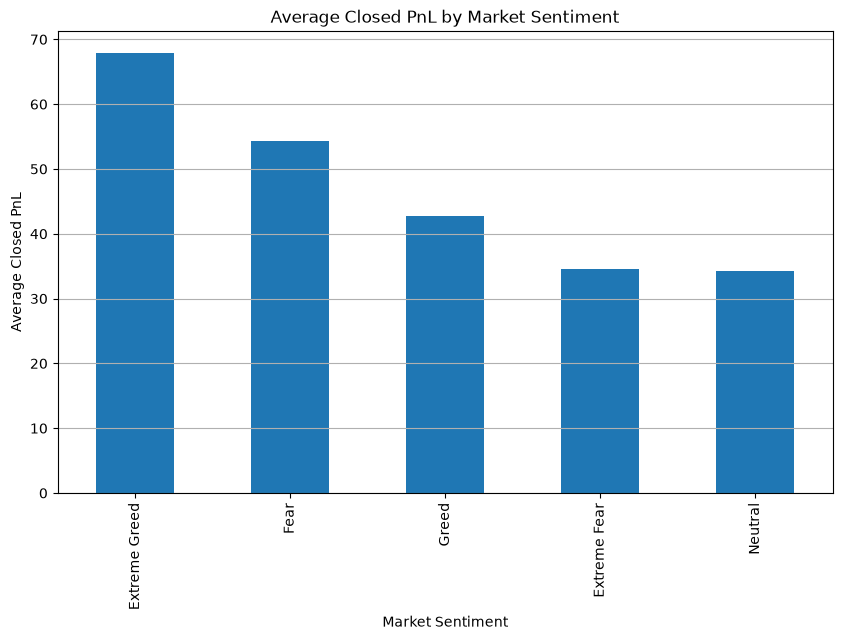

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sentiment_profit["mean"].plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.grid(axis="y")
plt.savefig("images/profit_by_sentiment.png", dpi=300, bbox_inches="tight")

plt.show()

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


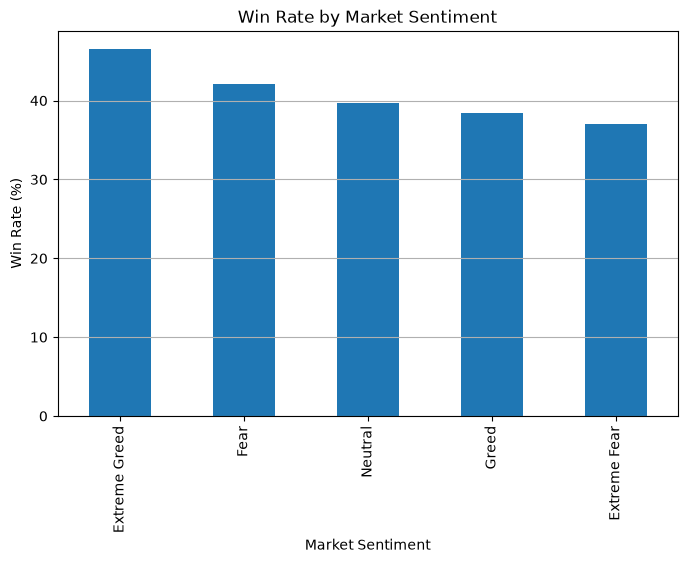

In [27]:
# Create Win/Loss column
merged_data["Win"] = merged_data["Closed PnL"] > 0

# Win rate by sentiment
win_rate = merged_data.groupby("classification")["Win"].mean() * 100

print(win_rate)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
win_rate.sort_values(ascending=False).plot(kind="bar")
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xlabel("Market Sentiment")
plt.grid(axis="y")
plt.savefig("images/win_rate_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

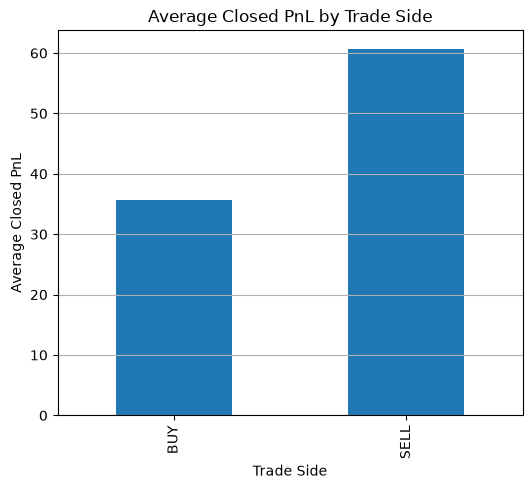

In [32]:
buy_sell = merged_data.groupby("Side")["Closed PnL"].agg(
    Trades="count",
    Average_PnL="mean",
    Total_PnL="sum"
)

plt.figure(figsize=(6,5))
buy_sell["Average_PnL"].plot(kind="bar")

plt.title("Average Closed PnL by Trade Side")
plt.xlabel("Trade Side")
plt.ylabel("Average Closed PnL")

plt.grid(axis="y")

plt.savefig("images/buy_vs_sell.png", dpi=300, bbox_inches="tight")

plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

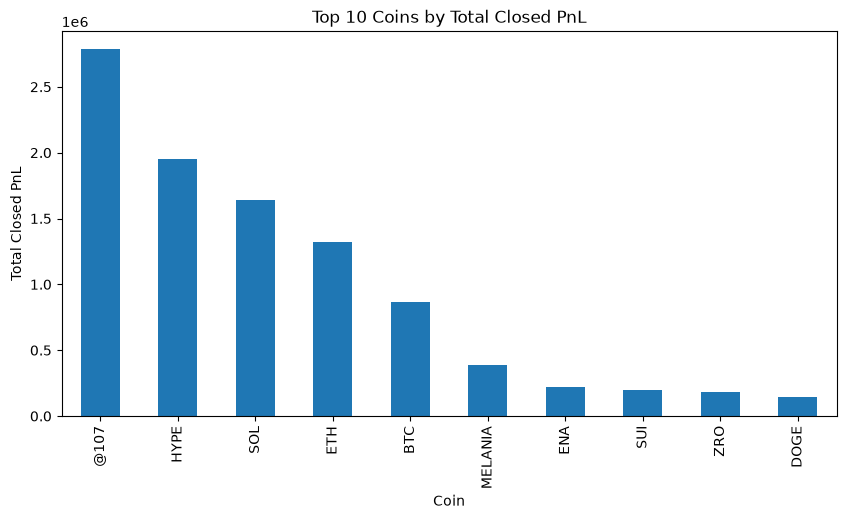

In [28]:
coin_profit = (
    merged_data
    .groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(coin_profit)

plt.figure(figsize=(10,5))
coin_profit.plot(kind="bar")
plt.title("Top 10 Coins by Total Closed PnL")
plt.ylabel("Total Closed PnL")
plt.savefig("images/top_profitable_coins.png", dpi=300, bbox_inches="tight")
plt.show()

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64

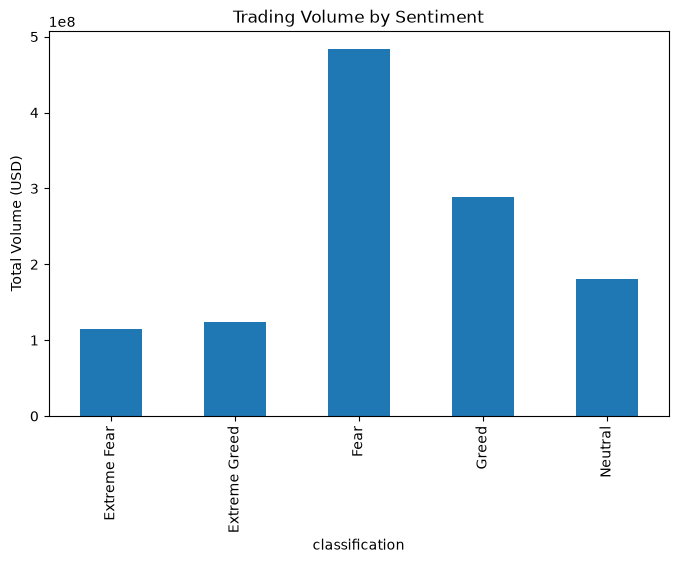

In [31]:
volume = merged_data.groupby("classification")["Size USD"].sum()

display(volume)

plt.figure(figsize=(8,5))
volume.plot(kind="bar")
plt.title("Trading Volume by Sentiment")
plt.ylabel("Total Volume (USD)")
plt.savefig("images/Trading Volume by Sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

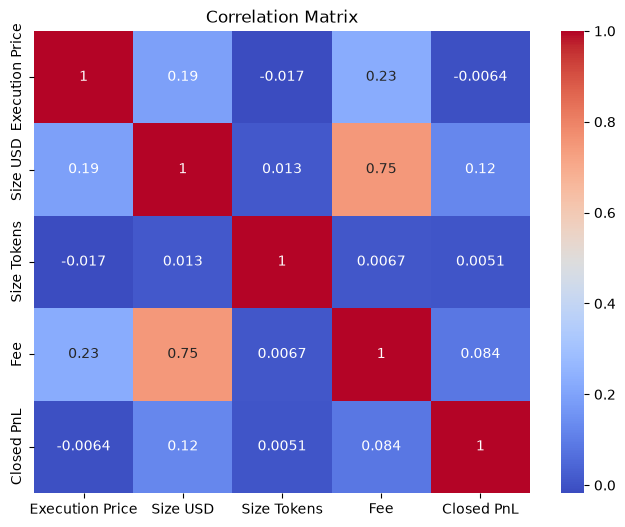

In [33]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    merged_data[
        ["Execution Price", "Size USD", "Size Tokens", "Fee", "Closed PnL"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.savefig("images/Correlation Matrix.png", dpi=300, bbox_inches="tight")
plt.show()